In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

In [2]:
# Load the patient readmission dataset
patient_data = pd.DataFrame({
    'age': np.random.normal(65, 15, 1000),
    'length_of_stay': np.random.normal(5, 2, 1000),
    'num_medications': np.random.normal(7, 3, 1000),
    'num_procedures': np.random.normal(2, 1, 1000),
    'num_lab_procedures': np.random.normal(10, 3, 1000),
    'num_diagnoses': np.random.normal(7, 2, 1000)
})

In [3]:
# Create target variable (readmitted within 30 days)
# Let's say readmission is more likely with longer stays and more medications
readmission_prob = (0.3 * (patient_data['length_of_stay'] > 5) + 
                   0.3 * (patient_data['num_medications'] > 8) +
                   0.4 * np.random.random(1000))
patient_data['readmitted'] = (readmission_prob > 0.5).astype(int)


In [4]:
# Split the dataset into features and target variable
X = patient_data.drop(columns=['readmitted'], axis=1)
y = patient_data['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# First, let's evaluate our initial model with cross-validation
initial_model = DecisionTreeClassifier(random_state=42)
initial_scores = cross_val_score(
    initial_model, X_train, y_train, cv=5, scoring='roc_auc'
)
print("Initial model performance:")
print(f"ROC-AUC: {initial_scores.mean():.3f} (+/- {initial_scores.std() * 2:.3f})")

Initial model performance:
ROC-AUC: 0.697 (+/- 0.089)


In [8]:
# Now let's implement our systematic tuning process
def evaluate_model_complexity():
    """Evaluate how model performance changes with tree depth"""
    max_depths = range(1, 20)
    train_scores = []
    val_scores = []
    
    for depth in max_depths:
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        
        train_scores.append(roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
        val_scores.append(np.mean(cross_val_score(
            model, X_train, y_train, cv=5, scoring='roc_auc'
        )))
    
    plt.figure(figsize=(10, 6))
    plt.plot(max_depths, train_scores, label='Training Score')
    plt.plot(max_depths, val_scores, label='Cross-validation Score')
    plt.xlabel('Maximum Tree Depth')
    plt.ylabel('ROC-AUC Score')
    plt.title('Model Complexity Analysis')
    plt.legend()
    plt.show()
    
    return max_depths, train_scores, val_scores

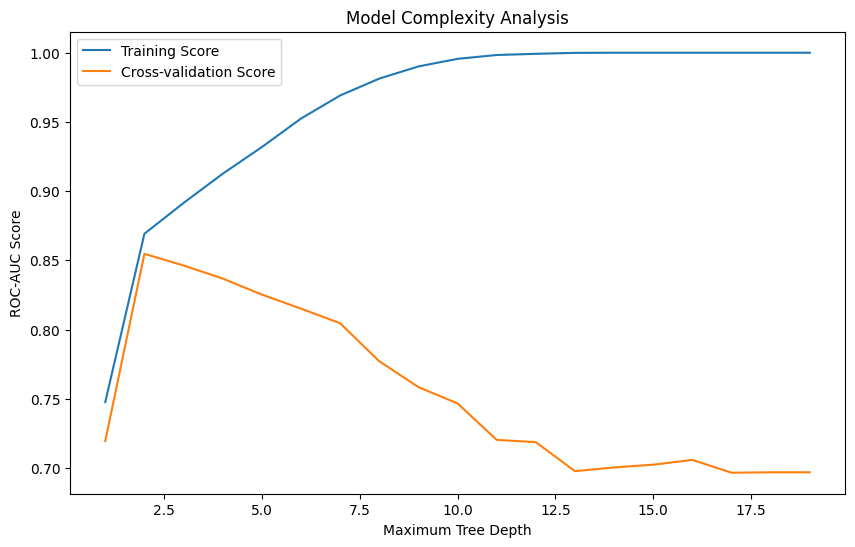

In [9]:
# Analyze model complexity
max_depths, train_scores, val_scores = evaluate_model_complexity()

In [10]:
# Based on the complexity analysis, let's do a focused grid search
param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [10, 20, 30, 40, 50],
    'min_samples_split': [20, 40, 60, 80, 100]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5, #For every combination of parameters, we will do 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1 #use all available cores to speed up the process
)

grid_search.fit(X_train, y_train)

# Evaluate our tuned model
final_model = grid_search.best_estimator_
final_scores = cross_val_score(
    final_model, X_train, y_train, cv=5, scoring='roc_auc'
)

# Evaluate the true test score performance
final_test_score = roc_auc_score(y_test, final_model.predict(X_test))

print("\nTuned model cv performance:")
print(f"Best parameters: {grid_search.best_params_}")
print(f"ROC-AUC: {final_scores.mean():.3f} (+/- {final_scores.std() * 2:.3f})")
print(f"Final Model ROC-AUC Evaluation on Test Data: {final_test_score:.3f}")


Tuned model cv performance:
Best parameters: {'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 20}
ROC-AUC: 0.867 (+/- 0.063)
Final Model ROC-AUC Evaluation on Test Data: 0.703


In [11]:
# Let's also look at feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
              feature  importance
1      length_of_stay    0.487626
2     num_medications    0.411533
4  num_lab_procedures    0.054736
3      num_procedures    0.032261
5       num_diagnoses    0.009994
0                 age    0.003850
